# Medical Insurance Cost Prediction

The objective of this project is to investigate the relationship between demographic and lifestyle characteristics and medical insurance charges.

Exploratory data analysis and linear regression models are used to identify important predictors of insurance costs, quantify their effects, and evaluate the ability of regression techniques to predict future charges.

Particular emphasis is placed on statistical interpretation, model assumptions, and the practical meaning of the results.


## Dataset Overview

The dataset contains information on individuals covered by a medical insurance plan. The available variables include demographic characteristics, health-related measurements, and insurance charges.

Before building predictive models, the dataset is inspected for missing values, duplicate observations, and variable types to ensure data quality and identify potential issues that may affect the analysis.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [53]:
df = pd.read_csv("medical_insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [55]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [56]:
df.drop_duplicates(inplace=True)
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Exploratory Data Analysis

Exploratory data analysis is used to understand the structure of the dataset and identify potential relationships between predictors and insurance charges.

This stage focuses on three main objectives:

* Understanding the distribution of individual variables.
* Detecting unusual observations and potential outliers.
* Investigating how each predictor relates to insurance charges.

The findings from this section will guide the regression modeling process and help assess whether the assumptions of linear regression are likely to be reasonable.

<Axes: xlabel='charges', ylabel='Count'>

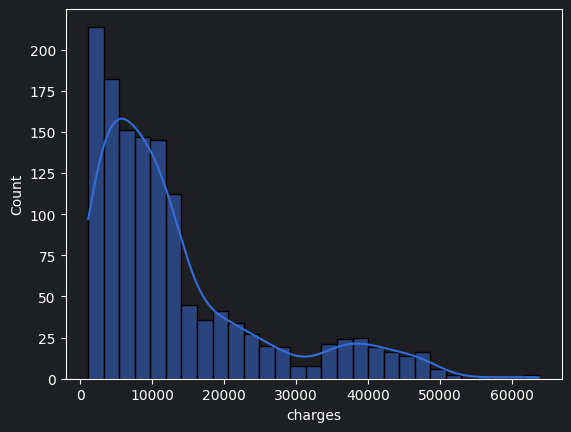

In [57]:
sns.histplot(data=df, x="charges", kde=True)

The distribution of insurance charges appears to be right-skewed

The presence of a right tail suggests that a subset of individuals incur substantially higher medical costs than the rest of the population.

This observation may have implications for the normality assumption used later in linear regression.

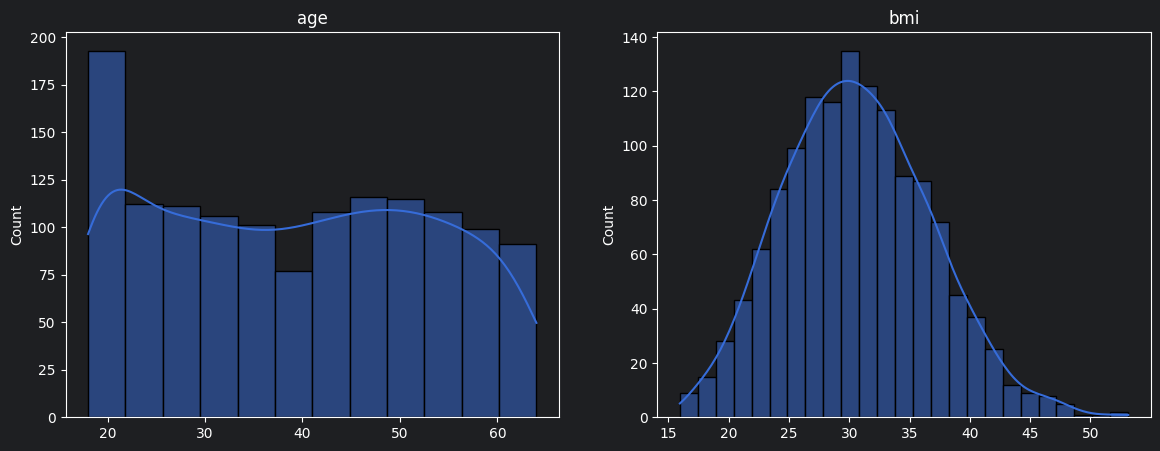

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
axes = ax.flatten()

continuos_cols = ['age', 'bmi']
for idx, col in enumerate(continuos_cols):
    sns.histplot(data=df, x=col, ax=axes[idx], kde=True)
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')


The age distribution is fairly uniform across most age groups, although a noticeably larger number of individuals are observed at age 20. After approximately age 50, the number of observations gradually decreases. Overall, the dataset contains individuals across a broad range of ages, providing good coverage for investigating the relationship between age and insurance charges.

The BMI distribution appears approximately symmetric and bell-shaped, suggesting that BMI values are relatively well distributed around the mean without substantial skewness.



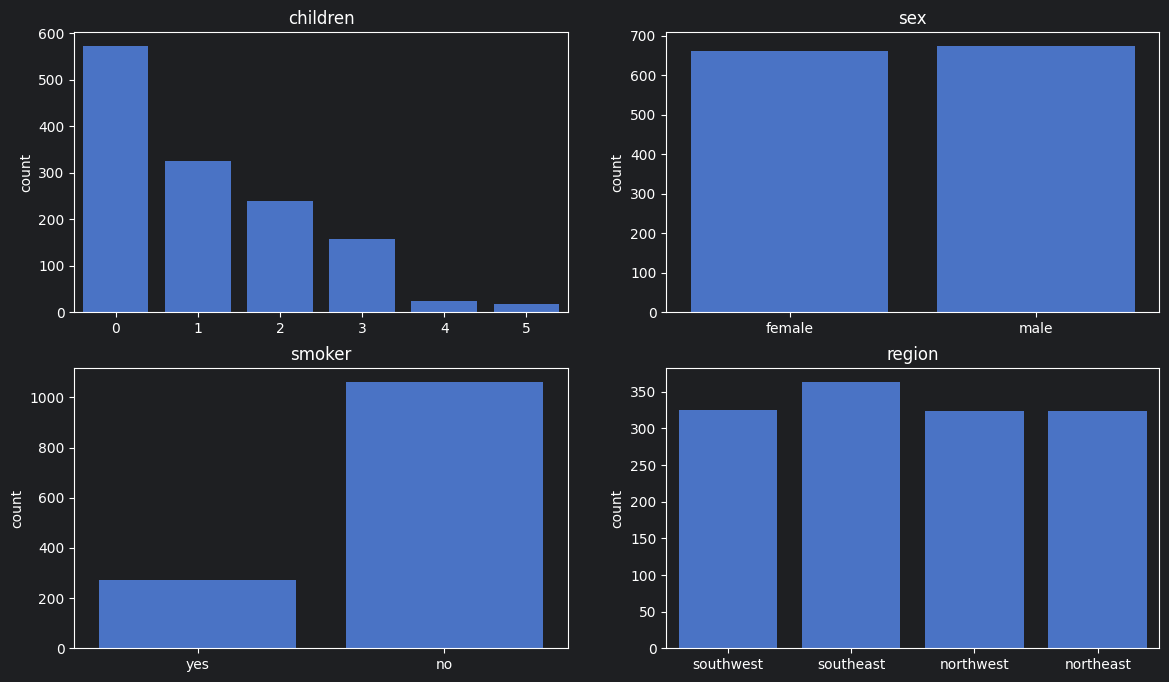

In [59]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
axes = ax.flatten()

categorical_cols = ['children', 'sex', 'smoker', 'region']

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

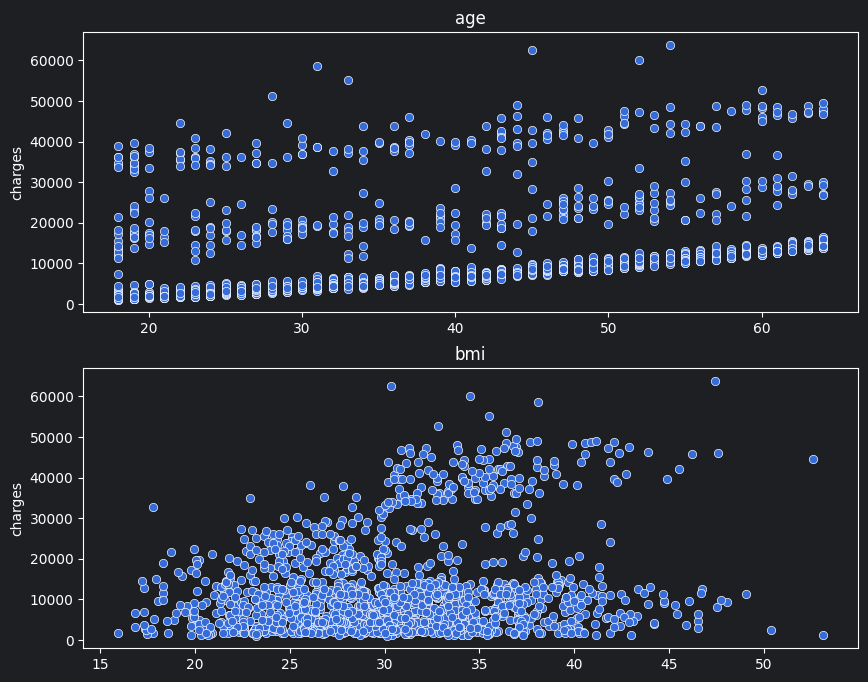

In [60]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
axes = ax.flatten()

for idx, col in enumerate(continuos_cols):
    sns.scatterplot(data=df, x=col, y='charges', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

A positive relationship between age and insurance charges is observed.

Older individuals generally appear to incur higher medical costs, although substantial variability exists within each age group.

The relationship appears approximately linear, suggesting that age may be a useful predictor in a regression model.

In regards to BMI there seems to exist a positive relationship when the BMI increases, but the relationship appears weaker than the relationship observed for age.

Potential nonlinear patterns and high-cost observations should be investigated further during model diagnostics.

### Investigating the BMI–Charges Relationship

Although higher BMI values are often associated with higher insurance charges, substantial variability remains unexplained. Individuals with similar BMI values can exhibit markedly different insurance costs, suggesting that BMI alone may not fully explain the observed pattern.

One possible explanation is that the relationship between BMI and charges may depend on another variable. For example, the effect of BMI may differ across age groups. To investigate this possibility, BMI and insurance charges are visualized separately by age category.


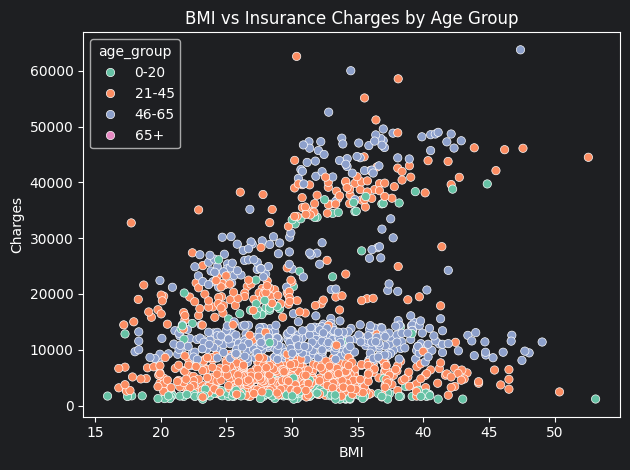

In [61]:
bins = [-1, 20, 45, 65, np.inf]
labels = ['0-20', '21-45', '46-65', '65+']

# 2. Create the binned column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# 3. Create the scatter plot
sns.scatterplot(data=df, x='bmi', y='charges', hue='age_group', palette='Set2')

# Optional: Adjust the plot details
plt.title('BMI vs Insurance Charges by Age Group')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.tight_layout()


The relationship between BMI and insurance charges remains highly variable across age groups.

Although higher BMI values are sometimes associated with higher charges, many individuals with elevated BMI exhibit costs comparable to those with lower BMI values.

Age alone does not appear to explain the variability observed in the BMI–charges relationship, suggesting that additional factors may influence insurance costs.

Further investigation may help identify whether other predictors contribute to this pattern.


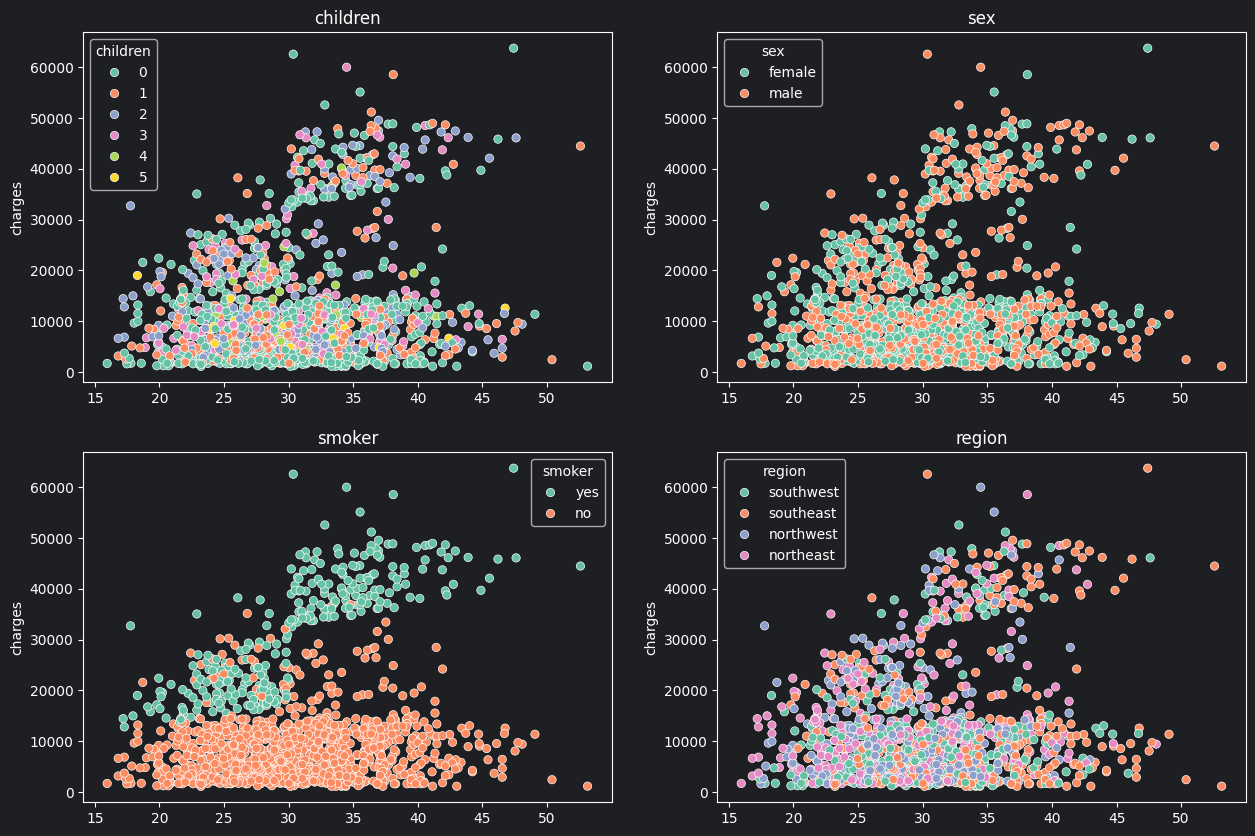

In [62]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
axes = ax.flatten()

categorical_cols = ['children', 'sex', 'smoker', 'region']

for idx, col in enumerate(categorical_cols):
    sns.scatterplot(data=df, x='bmi', y='charges', hue=col, palette='Set2', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

Smoking status appears to explain a considerable portion of the variability observed in the relationship between BMI and insurance charges.

Among non-smokers, insurance charges remain relatively stable across BMI values. In contrast, smokers tend to exhibit substantially higher charges, particularly at higher BMI levels.

This finding suggests that smoking status may be one of the most important predictors in the dataset and highlights the possibility that the effect of BMI differs between smokers and non-smokers.

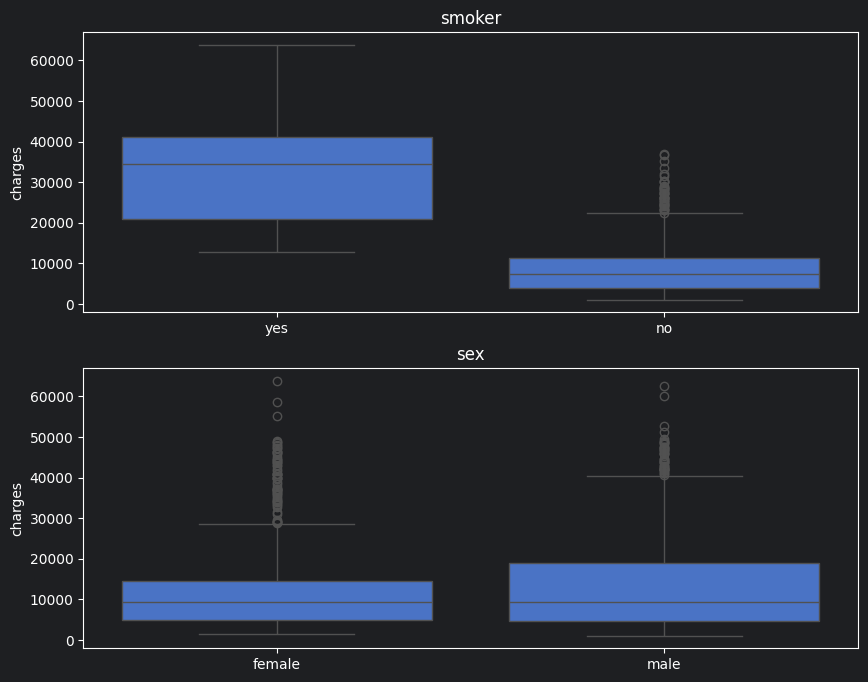

In [63]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
axes = ax.flatten()

binary_cols = ['smoker', 'sex']

for idx, col in enumerate(binary_cols):
    sns.boxplot(data=df, x=col, y='charges', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

As highlighted previously, a substantial difference in insurance charges is observed between smokers and non-smokers.

The median and overall distribution of charges are considerably higher among smokers, suggesting that smoking status may be one of the most important predictors in the dataset.

This result supports the hypothesis that lifestyle-related risk factors are strongly associated with medical costs.

There does not appear to be a strong relationship between sex and insurance charges. However, the distribution of charges among males appears to exhibit greater variability than that of females, as evidenced by the wider spread of observations.

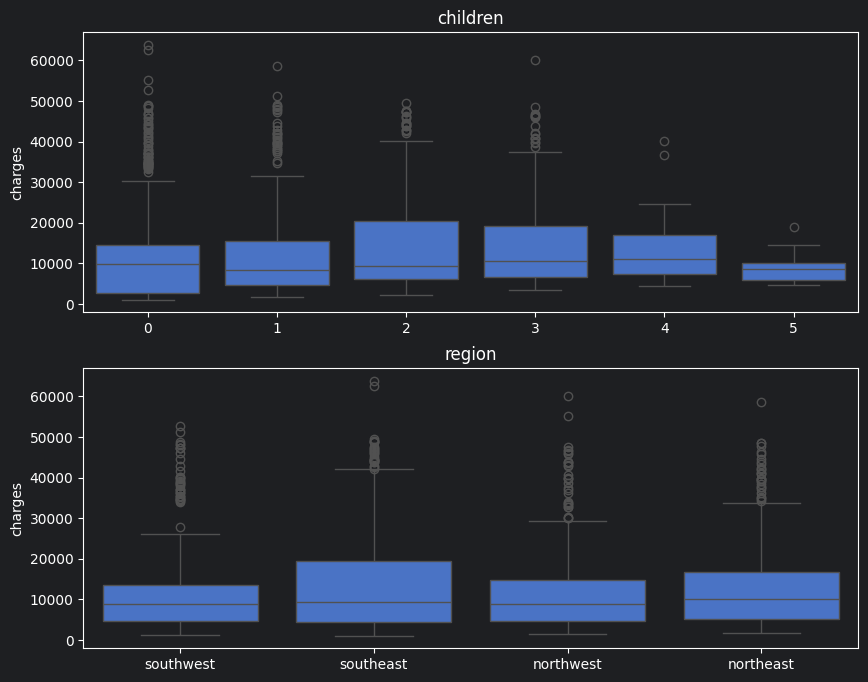

In [64]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
axes = ax.flatten()

multi_category_cols = ['children', 'region']


for idx, col in enumerate(multi_category_cols):
    sns.boxplot(data=df, x=col, y='charges', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')


The median insurance charges appear relatively similar across the different numbers of children, suggesting that the number of dependents may not have a strong association with insurance costs.

Some differences in variability are observed, with individuals reporting two or three children exhibiting a wider spread of charges than the other groups. However, the substantial overlap between the distributions suggests that any relationship between the number of children and insurance charges is likely weaker than those observed for variables such as age, BMI, or smoking status.

Insurance charges appear broadly similar across the four regions, with substantial overlap between their distributions.

The Southeast region exhibits greater variability and contains a larger number of high-cost observations than the other regions. However, the Southeast region also contains a slightly larger number of individuals, which may partially contribute to the greater spread observed in the boxplot.

Overall, region does not appear to have as strong an association with insurance charges as smoking status or age.

<Axes: >

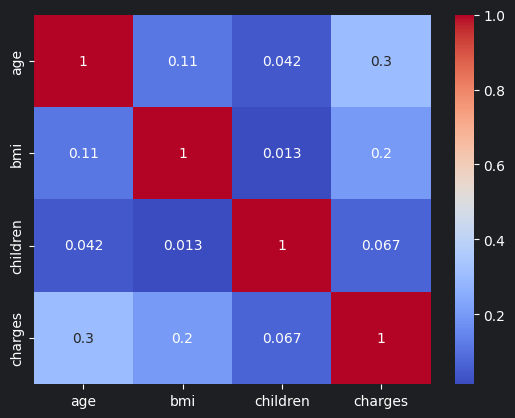

In [65]:
sns.heatmap(
    df[['age','bmi','children','charges']].corr(),
    annot=True,
    cmap='coolwarm'
)

## Correlation Analysis

The correlation matrix summarizes the linear relationships among the numerical variables in the dataset.

Age exhibits the strongest correlation with insurance charges (approximately 0.30), followed by BMI (approximately 0.20). Both correlations are positive, indicating that higher age and BMI values tend to be associated with higher insurance costs.

However, the correlations are relatively modest, suggesting that these variables alone do not fully explain the variation in insurance charges. This finding is consistent with the exploratory analysis, which indicated that additional factors may play an important role in determining insurance costs.

It is important to note that correlation only measures linear relationships between numerical variables. Consequently, potentially important categorical predictors, such as smoking status, are not represented in this analysis.


## Summary of Exploratory Findings

Several variables appear to be associated with insurance charges. Age and BMI exhibit positive relationships with charges, although substantial variability remains unexplained by either variable individually.

Smoking status emerges as the strongest predictor identified during the exploratory analysis, with smokers exhibiting considerably higher insurance costs than non-smokers.

The exploratory analysis also suggests that the relationship between BMI and insurance charges may differ according to smoking status. These findings motivate the use of regression models to quantify the effects of the predictors and evaluate their ability to explain variation in insurance charges.


## Simple Linear Regression: Age and Insurance Charges

The exploratory analysis suggested a positive relationship between age and insurance charges. To quantify this relationship, a simple linear regression model is fitted using age as the sole predictor.

This model estimates the average change in insurance charges associated with a one-year increase in age and provides an initial assessment of the predictive value of age.

In addition to prediction, the model allows statistical inference through confidence intervals and hypothesis tests.


### Model Specification

To fit a simple linear regression model, age is selected as the predictor variable and insurance charges as the response variable.

An intercept term is added to the model so that the regression equation can estimate both the baseline insurance charge and the average change in charges associated with age.


In [66]:
X = df[['age']]
y = df['charges']

X = sm.add_constant(X)

### Model Estimation

Ordinary Least Squares (OLS) regression is used to estimate the relationship between age and insurance charges. The fitted model provides estimates of the regression coefficients as well as statistical measures used for inference and model evaluation.


In [67]:
model_age = sm.OLS(y, X).fit()

print(model_age.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     130.4
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           6.98e-29
Time:                        21:26:36   Log-Likelihood:                -14405.
No. Observations:                1337   AIC:                         2.881e+04
Df Residuals:                    1335   BIC:                         2.882e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3190.0217    938.396      3.399      0.0

The fitted model indicates a positive relationship between age and insurance charges. On average, a one-year increase in age is associated with an increase of approximately 257 monetary units in predicted insurance charges.

The age coefficient is statistically significant (p < 0.001), providing strong evidence of an association between age and insurance costs. The 95% confidence interval suggests that the true increase in charges associated with a one-year increase in age lies between approximately 213 and 301 monetary units.

However, the model explains only 8.9% of the variability in insurance charges (R² = 0.089). Although age appears to be an important predictor, a substantial portion of the variation in insurance costs remains unexplained, suggesting that additional variables should be considered.


## Simple Linear Regression: BMI and Insurance Charges

The exploratory analysis indicated a positive relationship between BMI and insurance charges, although the relationship appeared weaker and more variable than that observed for age.

A simple linear regression model is fitted using BMI as the sole predictor to quantify this relationship and evaluate its ability to explain variation in insurance charges.


In [68]:
X = df[['bmi']]
y = df['charges']

X = sm.add_constant(X)

model_bmi = sm.OLS(y, X).fit()

print(model_bmi.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.70
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.47e-13
Time:                        21:26:36   Log-Likelihood:                -14440.
No. Observations:                1337   AIC:                         2.888e+04
Df Residuals:                    1335   BIC:                         2.889e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1202.1404   1664.857      0.722      0.4

The fitted model indicates a positive relationship between BMI and insurance charges. On average, a one-unit increase in BMI is associated with an increase of approximately 394 monetary units in predicted insurance charges.

The BMI coefficient is statistically significant (p < 0.001), providing strong evidence of an association between BMI and insurance costs. The 95% confidence interval suggests that the true increase in charges associated with a one-unit increase in BMI lies between approximately 289 and 498 monetary units.

However, the model explains only 3.9% of the variability in insurance charges (R² = 0.039). Although BMI appears to be associated with insurance costs, most of the variation remains unexplained. This result is consistent with the exploratory analysis, which suggested that additional variables may influence the relationship between BMI and insurance charges.


## Multiple Linear Regression

The simple regression models demonstrated that age and BMI are individually associated with insurance charges. However, neither variable explained a large proportion of the variation in costs.

To better understand the combined effects of the available predictors, a multiple linear regression model is fitted using all variables in the dataset. This approach allows the relationship between each predictor and insurance charges to be evaluated while accounting for the influence of the remaining variables.


In [69]:
model_full = smf.ols(
    formula='charges ~ age + bmi + children + sex + smoker + region',
    data=df
).fit()

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:26:36   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    

### Interpretation

The multiple regression model explains approximately 75.1% of the variability in insurance charges (R² = 0.751), representing a substantial improvement over the simple regression models. This indicates that the predictors collectively provide a strong explanation of insurance costs.

Smoking status emerges as the strongest predictor in the model. Holding all other variables constant, smokers are predicted to incur approximately 23,850 additional monetary units in insurance charges compared with non-smokers.

Age, BMI, and the number of children are also statistically significant predictors. The model estimates that insurance charges increase by approximately 257 monetary units for each additional year of age, 339 monetary units for each additional BMI unit, and 475 monetary units for each additional child, after accounting for the remaining predictors.

Sex does not appear to be a statistically significant predictor after adjusting for the other variables. Regional differences are generally small, although some regions exhibit statistically significant differences relative to the reference region.

Overall, the results suggest that smoking status is the dominant predictor of insurance charges, while age, BMI, and number of children provide additional explanatory power.


## Model Diagnostics

Multiple linear regression relies on several assumptions regarding the residuals and the relationship between the predictors and the response variable.

Diagnostic plots are used to assess whether these assumptions appear reasonable and to identify potential issues that may affect the reliability of the model.

Particular attention is given to the distribution of residuals, the presence of non-constant variance, and potential outliers.


In [70]:
residuals = model_full.resid
fitted = model_full.fittedvalues

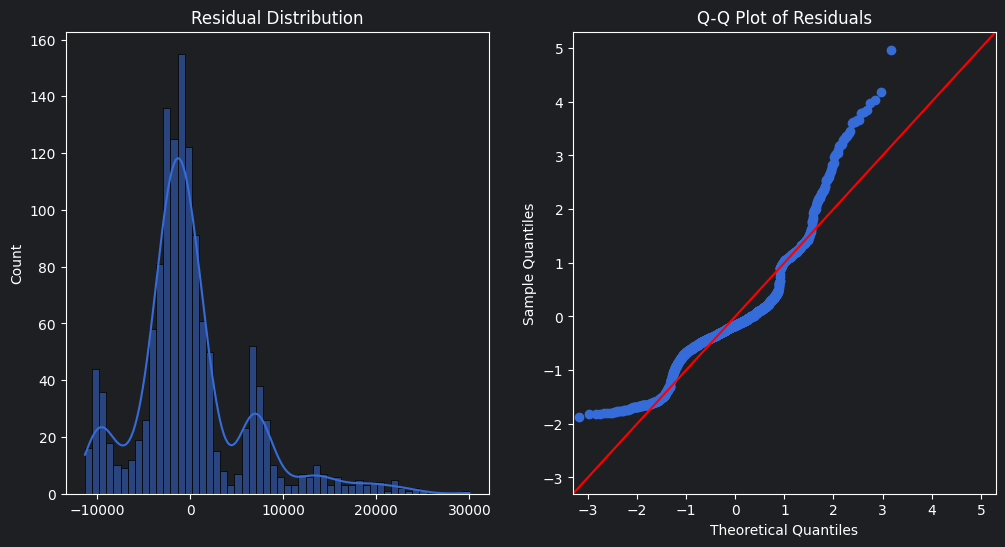

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
axes = ax.flatten()

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Residual Distribution')

sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
plt.show()


### Residual Distribution

The residuals are centered around zero, suggesting that the model does not systematically overestimate or underestimate insurance charges.

However, the residual distribution exhibits noticeable right skewness and deviates from the bell-shaped pattern expected under normality. This observation is consistent with the earlier exploratory analysis, which revealed a strongly right-skewed distribution of insurance charges.

Further diagnostic analysis is required to assess whether additional model assumptions appear reasonable.

### Q-Q Plot of Residuals

The Q-Q plot indicates that the residuals deviate from the normal distribution, particularly in the tails. While observations near the center of the distribution follow the reference line reasonably closely, substantial departures are observed for larger residuals.

The upper tail exhibits the strongest deviation, suggesting the presence of more extreme positive residuals than would be expected under normality. This finding is consistent with the residual histogram and with the right-skewed distribution of insurance charges observed during the exploratory analysis.

Although the normality assumption is not perfectly satisfied, the large sample size reduces the practical impact of these deviations on the regression estimates.


Text(0.5, 1.0, 'Residuals vs Fitted Values')

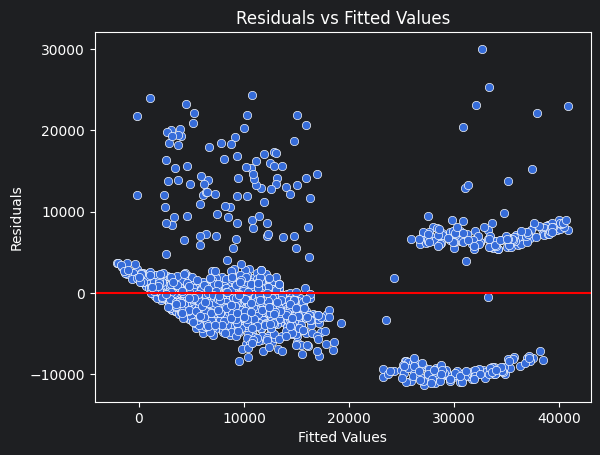

In [72]:
residuals = model_full.resid
fitted = model_full.fittedvalues

sns.scatterplot(
    x=fitted,
    y=residuals
)

plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

### Residuals vs Fitted Values

The residuals are not randomly scattered around zero and exhibit visible patterns across the range of fitted values. Several clusters and curved structures are present, suggesting that the model may not fully capture all of the relationships in the data.

These patterns indicate that some model assumptions may not be completely satisfied and that additional model refinement could potentially improve predictive performance.

One possible explanation is that the relationship between certain predictors and insurance charges differs across groups of individuals, an issue that may warrant further investigation.


## Investigating a BMI–Smoking Interaction

The exploratory analysis suggested that the relationship between BMI and insurance charges may differ according to smoking status. In particular, higher BMI values appeared to be associated with substantially larger insurance charges among smokers than among non-smokers.

To investigate this possibility, an interaction term between BMI and smoking status is added to the multiple regression model. This allows the effect of BMI on insurance charges to vary between smokers and non-smokers.


In [73]:
model_interaction = smf.ols(
    formula='charges ~ age + bmi + children + sex + smoker + region + bmi:smoker',
    data=df
).fit()

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     778.8
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:26:36   Log-Likelihood:                -13238.
No. Observations:                1337   AIC:                         2.650e+04
Df Residuals:                    1327   BIC:                         2.655e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -2222.3383    

### Interpretation

Adding an interaction term between BMI and smoking status substantially improves the model, increasing the coefficient of determination from 0.751 to 0.841. This suggests that the relationship between BMI and insurance charges differs according to smoking status.

The interaction term is highly statistically significant (p < 0.001), providing strong evidence that the effect of BMI is not the same for smokers and non-smokers.

After introducing the interaction, the BMI coefficient is no longer statistically significant for the reference group. This indicates that BMI alone has a relatively small association with insurance charges among non-smokers. However, among smokers, the effect of BMI is substantially larger, suggesting that increases in BMI are associated with much greater increases in insurance costs for smokers than for non-smokers.

These findings are consistent with the exploratory analysis and demonstrate how interaction effects can reveal relationships that are not captured by standard additive regression models.


## Model Evaluation

The previous analyses assessed how well the regression model explained variation in the observed data. However, a model that performs well on the training data may not necessarily generalize well to new observations.

To evaluate predictive performance, the data is divided into training and testing sets. The model is fitted using the training data and evaluated on the testing data using several performance metrics, including the coefficient of determination (R²), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).


### Data Preparation

Before fitting the predictive model, the dataset is transformed into a numerical format suitable for machine learning algorithms.

Binary categorical variables are encoded as indicator variables, while the region variable is converted into dummy variables to represent the different categories without introducing an artificial ordering. In addition, an interaction feature between BMI and smoking status is created based on the findings of the regression analysis, which suggested that the relationship between BMI and insurance charges differs between smokers and non-smokers.

These transformations allow the predictive model to incorporate both categorical information and interaction effects identified during the statistical analysis.


In [74]:
df_transformed = df.drop(columns=['age_group']).copy()

df_transformed['sex'] = df_transformed['sex'].map({
    'female': 0,
    'male': 1
})

df_transformed['smoker'] = df_transformed['smoker'].map({
    'no': 0,
    'yes': 1
})

df_transformed['smoker_bmi'] = (
    df_transformed['smoker']
    * df_transformed['bmi']
)

df_transformed = pd.get_dummies(
    df_transformed,
    columns=['region'],
    drop_first=True,
    dtype=int
)

df_transformed.head()

,age,sex,bmi,children,smoker,charges,smoker_bmi,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,27.9,0,0,1
1,18,1,33.770,1,0,1725.55230,0.0,0,1,0
2,28,1,33.000,3,0,4449.46200,0.0,0,1,0
3,33,1,22.705,0,0,21984.47061,0.0,1,0,0
4,32,1,28.880,0,0,3866.85520,0.0,1,0,0


In [75]:
df_transformed.dtypes

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
smoker_bmi          float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

### Training and Testing Sets

To evaluate the predictive performance of the model, the dataset is divided into training and testing sets.

The training set is used to estimate the model parameters, while the testing set is reserved for evaluating predictive performance on previously unseen observations. This approach provides a more realistic assessment of how well the model is expected to generalize to new data.


In [76]:
from sklearn.model_selection import train_test_split

X = df_transformed.drop(columns='charges')
y = df_transformed['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [79]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R²: 0.886
MAE: 2828.97
RMSE: 4572.81


### Predictive Performance

The model achieved strong predictive performance on the testing data, with an R² value of 0.886. This indicates that approximately 88.6% of the variation in insurance charges is explained by the model when applied to previously unseen observations.

The mean absolute error (MAE) was approximately 2,829 monetary units, indicating that predictions differed from the observed charges by about this amount on average. The root mean squared error (RMSE) was approximately 4,573 monetary units, suggesting that some observations still exhibit relatively large prediction errors.

Overall, the results indicate that the model generalizes well to new data and provides accurate predictions of insurance charges.


Text(0.5, 1.0, 'Actual vs Predicted Charges')

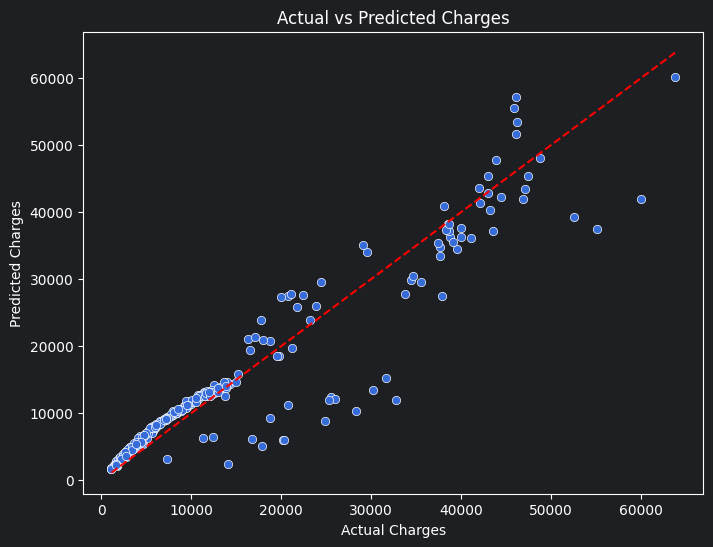

In [80]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

## Conclusions

The objective of this project was to investigate the factors associated with medical insurance charges and to develop a model capable of predicting insurance costs.

The exploratory analysis identified age, BMI, and smoking status as potentially important predictors of insurance charges. In particular, smoking status exhibited a strong relationship with medical costs, while the relationship between BMI and charges appeared to vary considerably across individuals.

Simple linear regression models confirmed that both age and BMI were positively associated with insurance charges, although each variable individually explained only a small proportion of the observed variability. A multiple linear regression model substantially improved explanatory power and identified smoking status as the most influential predictor.

Further investigation revealed a significant interaction between BMI and smoking status. Incorporating this interaction improved model performance considerably, indicating that the effect of BMI on insurance charges differs between smokers and non-smokers. Among smokers, increases in BMI were associated with substantially larger increases in insurance costs.

The final model achieved strong predictive performance on unseen data, explaining approximately 88.6% of the variation in insurance charges. Overall, the results suggest that smoking status, age, BMI, and their interaction play important roles in explaining medical insurance costs.

The project demonstrates how exploratory analysis, statistical inference, regression modeling, and predictive evaluation can be combined to understand real world problems such as predicting medical insurance costs.


## Limitations

Several limitations should be considered when interpreting the results of this analysis.

First, the dataset contains a relatively small number of predictors. Insurance costs are likely influenced by additional factors such as medical history, chronic conditions, income, healthcare utilization, and lifestyle characteristics that are not available in the dataset.

Second, diagnostic analyses indicated departures from the normality assumption, particularly in the upper tail of the residual distribution. Although the large sample size reduces the practical impact of these deviations, they suggest that the model does not fully capture all sources of variation in insurance charges.

Third, the analysis identifies statistical associations rather than causal relationships. While variables such as smoking status are strongly associated with insurance charges, the regression models alone cannot establish causation.

Finally, the results are specific to the population represented in the dataset and may not generalize to different insurance systems, geographic regions, or populations with substantially different characteristics.

Future work could investigate additional predictors, alternative regression approaches, or more flexible machine learning models to further improve predictive performance.